# 02 - Generalized ResUNet Reconstruction for Sparse-View CT

Train and evaluate one ResUNet that maps FBP proxy inputs to clean CT images across all sparse-view settings.

## 1. Environment Setup and Imports

Install dependencies, mount Drive, and import the required libraries.

In [1]:
!pip install astra-toolbox

from google.colab import drive

drive.mount("/content/drive")

import sys
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# Paths setup
PROJECT_ROOT = Path("/content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING")
PROCESSED_DIR = PROJECT_ROOT / "processed2"
WEIGHTS_DIR = PROJECT_ROOT / "weights" / "unet"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "unet"

for directory in [WEIGHTS_DIR, OUTPUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

sys.path.append(str(PROJECT_ROOT))

from IPPy import models, operators, solvers, utilities
from IPPy.utilities import normalize
from IPPy.utilities.metrics import PSNR, SSIM

# Global Configuration
SEED = 42
IMAGE_SIZE = 256
DETECTOR_SIZE = 256
GEOMETRY = "parallel"
ANGLE_COUNTS = (180, 90, 60, 45)  # The network will be trained on all of these

# ==========================================
# HYPERPARAMETERS TUNING
# ==========================================
MODEL_FINAL_ACTIVATION = None
LEARNING_RATE = 1e-4
MIN_LEARNING_RATE = 1e-6
LR_REDUCTION_FACTOR = 0.5
LR_SCHEDULER_PATIENCE = 2
BASE_CHANNELS = 32
BATCH_SIZE = 8
NUM_EPOCHS = 30
PATIENCE = 10
BEST_LOSS_TOLERANCE = 1e-8
# ==========================================

RESUME_TRAINING = True
CHECKPOINT_PATH = WEIGHTS_DIR / "resunet_generalized_latest.pt"
BEST_CHECKPOINT_PATH = WEIGHTS_DIR / "resunet_generalized_best.pt"

torch.manual_seed(SEED)
np.random.seed(SEED)

device = utilities.get_device()
if str(device) == "cuda":
    torch.cuda.manual_seed_all(SEED)

print("Device used:", device)
if str(device) == "cuda":
    print("CUDA device:", torch.cuda.get_device_name(0))
print("Training on all view configurations:", ANGLE_COUNTS)
print("Model final activation:", MODEL_FINAL_ACTIVATION)
print("Processed data directory:", PROCESSED_DIR)
print("UNet weights directory:", WEIGHTS_DIR)
print("Latest checkpoint path:", CHECKPOINT_PATH)
print("Best checkpoint path:", BEST_CHECKPOINT_PATH)
print("UNet outputs directory:", OUTPUT_DIR)

  Using cached astra_toolbox-2.4.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.3 kB)
  Using cached nvidia_cuda_runtime_cu12-12.9.79-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.7 kB)
  Using cached nvidia_cufft_cu12-11.4.1.4-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.7/39.7 MB 21.6 MB/s eta 0:00:00
Mounted at /content/drive
Device used: cpu
Training on all view configurations: (180, 90, 60, 45)
Model final activation: None
Processed data directory: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/processed2
UNet weights directory: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/weights/unet
Latest checkpo

## 2. Load the Preprocessed Data Contract

Load processed patient files and verify clean image and sinogram shapes.

In [2]:
manifest_path = PROCESSED_DIR / "manifest.json"
with manifest_path.open("r", encoding="utf-8") as file:
    manifest = json.load(file)

def collect_processed_patients(split_name: str) -> list[Path]:
    split_info = manifest["splits"][split_name]
    return [PROCESSED_DIR / record["path"] for record in split_info["patients"]]

processed_patients = {
    "train": collect_processed_patients("train"),
    "val": collect_processed_patients("val"),
    "test": collect_processed_patients("test"),
}

for split_name, patient_paths in processed_patients.items():
    num_images = manifest["splits"][split_name]["num_images"]
    print(f"{split_name} split: {num_images} images across {len(patient_paths)} patients")

example_payload = torch.load(processed_patients["train"][0], map_location="cpu")
print(f"Example clean shape: {tuple(example_payload['clean'].shape)}")
for views in ANGLE_COUNTS:
    print(f"Example sinogram ({views} views) shape: {tuple(example_payload['sinograms'][str(views)].shape)}")

train split: 2585 images across 8 patients
val split: 721 images across 2 patients
test split: 327 images across 1 patients
Example clean shape: (278, 1, 256, 256)
Example sinogram (180 views) shape: (278, 1, 180, 256)
Example sinogram (90 views) shape: (278, 1, 90, 256)
Example sinogram (60 views) shape: (278, 1, 60, 256)
Example sinogram (45 views) shape: (278, 1, 45, 256)


## 3. FBP Proxy Setup

Create one CT projector and FBP solver for each sparse-view configuration.

In [3]:
projectors = {
    str(n_views): operators.CTProjector(
        img_shape=(IMAGE_SIZE, IMAGE_SIZE),
        angles=np.linspace(0.0, np.pi, n_views),
        det_size=DETECTOR_SIZE,
        geometry=GEOMETRY,
    )
    for n_views in ANGLE_COUNTS
}

fbp_solvers = {angle_key: solvers.FBP(projector) for angle_key, projector in projectors.items()}

def normalize_batch_per_image(batch: torch.Tensor) -> torch.Tensor:
    normalized = []
    for image in batch:
        normalized.append(normalize(image.unsqueeze(0)).clamp(0.0, 1.0).to(torch.float32))
    return torch.cat(normalized, dim=0)

@torch.no_grad()
def compute_fbp_proxy(sinogram: torch.Tensor, angle_key: str) -> torch.Tensor:
    sinogram = sinogram.to(device)
    fbp, _ = fbp_solvers[angle_key](sinogram, x_true=None, starting_point=None)
    return normalize_batch_per_image(fbp.detach())


CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. U

## 4. PyTorch Dataset and DataLoader

Build datasets and dataloaders from clean images and matching sinogram dictionaries.

In [4]:
class PatientSinogramDataset(Dataset):
    def __init__(self, patient_paths: list[Path]):
        self.patient_paths = list(patient_paths)

    def __len__(self):
        return len(self.patient_paths)

    def __getitem__(self, idx):
        patient_path = self.patient_paths[idx]
        payload = torch.load(patient_path, map_location="cpu")
        return {
            "sinograms": {key: val.detach().to(torch.float32) for key, val in payload["sinograms"].items()},
            "clean": payload["clean"].detach().to(torch.float32),
        }

def make_loader(patient_paths: list[Path], shuffle: bool) -> DataLoader:
    dataset = PatientSinogramDataset(patient_paths)
    return DataLoader(dataset, batch_size=None, shuffle=shuffle, num_workers=0)

def iter_slice_batches(patient_batch: dict, angle_key: str, batch_size: int = BATCH_SIZE):
    sinogram = torch.nan_to_num(patient_batch["sinograms"][angle_key].to(torch.float32), nan=0.0, posinf=0.0, neginf=0.0)
    clean = torch.nan_to_num(patient_batch["clean"].to(torch.float32), nan=0.0, posinf=1.0, neginf=0.0).clamp(0.0, 1.0)
    for start in range(0, clean.shape[0], batch_size):
        end = start + batch_size
        yield sinogram[start:end], clean[start:end]

## 5. ResUNet Architecture

Define the residual U-Net architecture used for image-domain reconstruction.

In [5]:
model = models.UNet(
    ch_in=1,
    ch_out=1,
    middle_ch=(BASE_CHANNELS, 2 * BASE_CHANNELS, 4 * BASE_CHANNELS, 8 * BASE_CHANNELS, 16 * BASE_CHANNELS),
    n_layers_per_block=2,
    down_layers=(
        "ResDownBlock",
        "ResDownBlock",
        "ResDownBlock",
        "ResDownBlock",
    ),
    up_layers=(
        "ResUpBlock",
        "ResUpBlock",
        "ResUpBlock",
        "ResUpBlock",
    ),
    n_heads=None,
    final_activation=MODEL_FINAL_ACTIVATION,
).to(device)
model_device = next(model.parameters()).device
num_params = sum(param.numel() for param in model.parameters())
print(f"ResUNet successfully built. Total trainable parameters: {num_params / 1e6:.2f}M")
print("Model parameter device:", model_device)

ResUNet successfully built. Total trainable parameters: 28.09M
Model parameter device: cpu


## 6. Training the Single Generalized ResUNet Model

Train one ResUNet across all angle counts and save latest/best checkpoints.


In [6]:
train_loader = make_loader(processed_patients["train"], shuffle=True)
val_loader = make_loader(processed_patients["val"], shuffle=False)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_REDUCTION_FACTOR,
    patience=LR_SCHEDULER_PATIENCE,
    min_lr=MIN_LEARNING_RATE,
)
loss_fn = nn.MSELoss()
history = []
val_history = []
best_val_loss = float("inf")
epochs_without_improvement = 0
start_epoch = 0


def checkpoint_payload(epoch: int, train_loss: float, val_loss: float) -> dict:
    return {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "best_val_loss": best_val_loss,
        "epochs_without_improvement": epochs_without_improvement,
        "history": history,
        "val_history": val_history,
        "config": {
            "ANGLE_COUNTS": ANGLE_COUNTS,
            "IMAGE_SIZE": IMAGE_SIZE,
            "BASE_CHANNELS": BASE_CHANNELS,
            "BATCH_SIZE": BATCH_SIZE,
            "LEARNING_RATE": LEARNING_RATE,
            "MIN_LEARNING_RATE": MIN_LEARNING_RATE,
            "LR_REDUCTION_FACTOR": LR_REDUCTION_FACTOR,
            "LR_SCHEDULER_PATIENCE": LR_SCHEDULER_PATIENCE,
            "LR_SCHEDULER": "ReduceLROnPlateau",
            "MODEL_FINAL_ACTIVATION": MODEL_FINAL_ACTIVATION,
            "PATIENCE": PATIENCE,
        },
    }


def load_compatible_checkpoint():
    global start_epoch, history, val_history, best_val_loss, epochs_without_improvement
    if RESUME_TRAINING and CHECKPOINT_PATH.exists():
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
        checkpoint_config = checkpoint.get("config", {})
        checkpoint_activation = checkpoint_config.get("MODEL_FINAL_ACTIVATION")
        has_activation_config = "MODEL_FINAL_ACTIVATION" in checkpoint_config
        if (not has_activation_config) or checkpoint_activation != MODEL_FINAL_ACTIVATION:
            print(
                "Checkpoint final activation is incompatible "
                f"({checkpoint_activation!r} != {MODEL_FINAL_ACTIVATION!r}). Starting from scratch."
            )
        else:
            model.load_state_dict(checkpoint["model_state_dict"])
            optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            checkpoint_scheduler = checkpoint_config.get("LR_SCHEDULER")
            if "scheduler_state_dict" in checkpoint and checkpoint_scheduler == "ReduceLROnPlateau":
                scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
            elif "scheduler_state_dict" in checkpoint:
                print(
                    "Checkpoint scheduler is incompatible "
                    f"({checkpoint_scheduler!r} != 'ReduceLROnPlateau'). Resetting optimizer lr."
                )
                for param_group in optimizer.param_groups:
                    param_group["lr"] = LEARNING_RATE
            else:
                print("Checkpoint has no scheduler state. Starting ReduceLROnPlateau from current optimizer lr.")
            start_epoch = int(checkpoint.get("epoch", 0))
            history = list(checkpoint.get("history", []))
            val_history = list(checkpoint.get("val_history", []))
            best_val_loss = float(checkpoint.get("best_val_loss", float("inf")))
            epochs_without_improvement = int(checkpoint.get("epochs_without_improvement", 0))
            print(f"Resuming training from checkpoint epoch {start_epoch}: {CHECKPOINT_PATH}")
    elif RESUME_TRAINING:
        print(f"RESUME_TRAINING=True, but no checkpoint found at {CHECKPOINT_PATH}. Starting from scratch.")
    else:
        print("RESUME_TRAINING=False. Starting training from scratch.")

load_compatible_checkpoint()

if start_epoch >= NUM_EPOCHS:
    print(f"Checkpoint is already at epoch {start_epoch}; NUM_EPOCHS={NUM_EPOCHS}. No training needed.")
else:
    print(f"Starting supervised training for Unified Generalized ResUNet model from epoch {start_epoch + 1} to {NUM_EPOCHS}...")

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        num_samples = 0
        progress = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [train]")

        for patient_batch in progress:
            for angle_key in [str(n) for n in ANGLE_COUNTS]:
                for sinogram_batch, clean_batch in iter_slice_batches(patient_batch, angle_key):
                    fbp_input = compute_fbp_proxy(sinogram_batch, angle_key).to(device)
                    clean_target = clean_batch.to(device)

                    optimizer.zero_grad(set_to_none=True)
                    prediction = model(fbp_input)
                    loss = loss_fn(prediction, clean_target)

                    if not torch.isfinite(loss):
                        raise RuntimeError("Non-finite loss encountered during training!")

                    loss.backward()
                    optimizer.step()

                    batch_size = clean_target.shape[0]
                    running_loss += loss.item() * batch_size
                    num_samples += batch_size
                    progress.set_postfix(train_loss=running_loss / num_samples)

        epoch_loss = running_loss / num_samples
        history.append(epoch_loss)

        model.eval()
        val_running_loss = 0.0
        val_num_samples = 0
        with torch.no_grad():
            for patient_batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [val]", leave=False):
                for angle_key in [str(n) for n in ANGLE_COUNTS]:
                    for sinogram_batch, clean_batch in iter_slice_batches(patient_batch, angle_key):
                        fbp_input = compute_fbp_proxy(sinogram_batch, angle_key).to(device)
                        clean_target = clean_batch.to(device)
                        prediction = model(fbp_input)
                        val_loss = loss_fn(prediction, clean_target)

                        batch_size = clean_target.shape[0]
                        val_running_loss += val_loss.item() * batch_size
                        val_num_samples += batch_size

        epoch_val_loss = val_running_loss / val_num_samples
        val_history.append(epoch_val_loss)
        improved = epoch_val_loss < best_val_loss - BEST_LOSS_TOLERANCE
        if improved:
            best_val_loss = epoch_val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        previous_lr = optimizer.param_groups[0]["lr"]
        scheduler.step(epoch_val_loss)
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch + 1}/{NUM_EPOCHS} | train loss: {epoch_loss:.6f} | "
            f"val loss: {epoch_val_loss:.6f} | lr: {current_lr:.2e}"
        )
        if current_lr < previous_lr:
            print(f"ReduceLROnPlateau reduced learning rate: {previous_lr:.2e} -> {current_lr:.2e}")

        payload = checkpoint_payload(epoch + 1, epoch_loss, epoch_val_loss)
        torch.save(payload, CHECKPOINT_PATH)

        if improved:
            torch.save(payload, BEST_CHECKPOINT_PATH)
            print(f"Saved best checkpoint after epoch {epoch + 1}: {BEST_CHECKPOINT_PATH}")

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping triggered after {PATIENCE} epochs without validation improvement.")
            break

Resuming training from checkpoint epoch 30: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/weights/unet/resunet_generalized_latest.pt
Checkpoint is already at epoch 30; NUM_EPOCHS=30. No training needed.


## 7. Unified Training Loss Curve

Plot loss across training epochs.

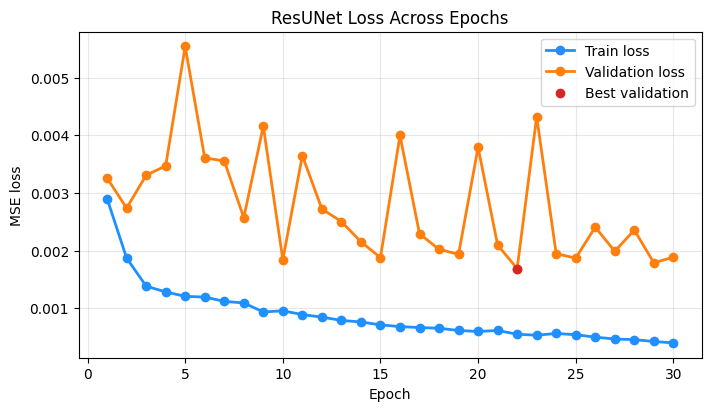

Saved training curve figure: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/outputs/unet/resunet_generalized_training_curve.png


In [7]:
training_curve_path = OUTPUT_DIR / "resunet_generalized_training_curve.png"

if not history:
    raise RuntimeError("Training history is empty. Run the training cell before plotting the loss curve.")

train_epochs = np.arange(1, len(history) + 1)
val_epochs = np.arange(1, len(val_history) + 1)

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(train_epochs, history, marker="o", linewidth=2, color="dodgerblue", label="Train loss")

if val_history:
    best_val_epoch = int(np.argmin(val_history)) + 1
    best_val_loss = val_history[best_val_epoch - 1]
    ax.plot(val_epochs, val_history, marker="o", linewidth=2, color="tab:orange", label="Validation loss")
    ax.scatter(best_val_epoch, best_val_loss, color="tab:red", zorder=3, label="Best validation")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("ResUNet Loss Across Epochs")
ax.grid(True, alpha=0.3)
ax.legend()
fig.savefig(training_curve_path, dpi=150)
plt.show()
plt.close(fig)

print("Saved training curve figure:", training_curve_path)

## 8. Generalization Test Set Evaluation and Metrics

Evaluate the best checkpoint on one representative test slice per angle count.

In [8]:
# Load best validation model weights. Fall back to latest only if no best checkpoint exists.
evaluation_checkpoint_path = BEST_CHECKPOINT_PATH if BEST_CHECKPOINT_PATH.exists() else CHECKPOINT_PATH
checkpoint = torch.load(evaluation_checkpoint_path, map_location=device)
checkpoint_config = checkpoint.get("config", {})
checkpoint_activation = checkpoint_config.get("MODEL_FINAL_ACTIVATION")
has_activation_config = "MODEL_FINAL_ACTIVATION" in checkpoint_config
if (not has_activation_config) or checkpoint_activation != MODEL_FINAL_ACTIVATION:
    raise RuntimeError(
        "Evaluation checkpoint is incompatible with the current model final activation "
        f"({checkpoint_activation!r} != {MODEL_FINAL_ACTIVATION!r}). Re-run training first."
    )
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded ResUNet checkpoint from epoch {checkpoint.get('epoch', 'unknown')}: {evaluation_checkpoint_path}")

# Load the first test patient
test_split = manifest["splits"]["test"]
patient_record = test_split["patients"][0]
patient_path = PROCESSED_DIR / patient_record["path"]
payload = torch.load(patient_path, map_location="cpu")

clean_images = payload["clean"].to(torch.float32)
sinograms = {key: val.to(torch.float32) for key, val in payload["sinograms"].items()}
metadata = payload["metadata"]
patient_id = metadata["patient_id"]

print(f"Loaded Test Patient ID: {patient_id}")

# Select the central slice
slice_idx = clean_images.shape[0] // 2
print(f"Evaluating on central test slice index: {slice_idx}")

x_true = clean_images[slice_idx : slice_idx + 1].to(device)

evaluation_results = {}
comparison_examples = {}

def compute_slice_metrics(prediction: torch.Tensor, clean: torch.Tensor) -> dict[str, float]:
    pred_eval = torch.clamp(prediction.detach(), 0.0, 1.0)
    clean_eval = torch.clamp(clean.detach().to(pred_eval.device), 0.0, 1.0)
    return {
        "psnr": float(PSNR(pred_eval, clean_eval)),
        "ssim": float(SSIM(pred_eval, clean_eval)),
    }

for angle_key in [str(n) for n in ANGLE_COUNTS]:
    y_delta = sinograms[angle_key][slice_idx : slice_idx + 1].to(device)
    fbp_input = compute_fbp_proxy(y_delta, angle_key).to(device)

    with torch.no_grad():
        prediction = torch.clamp(model(fbp_input), 0.0, 1.0)

    resunet_metrics = compute_slice_metrics(prediction, x_true)

    evaluation_results[angle_key] = {
        "resunet_psnr": resunet_metrics["psnr"],
        "resunet_ssim": resunet_metrics["ssim"],
    }

    comparison_examples[angle_key] = {
        "sinogram": y_delta.detach().cpu(),
        "fbp": fbp_input.detach().cpu(),
        "resunet": prediction.detach().cpu(),
        "clean": x_true.detach().cpu(),
    }

    print(f"\n{angle_key} views:")
    print(f"  ResUNet PSNR: {resunet_metrics['psnr']:.2f} dB | SSIM: {resunet_metrics['ssim']:.4f}")



Loaded ResUNet checkpoint from epoch 22: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/weights/unet/resunet_generalized_best.pt
Loaded Test Patient ID: C081
Evaluating on central test slice index: 163

180 views:
  ResUNet PSNR: 27.50 dB | SSIM: 0.8007

90 views:
  ResUNet PSNR: 27.89 dB | SSIM: 0.7959

60 views:
  ResUNet PSNR: 29.16 dB | SSIM: 0.8507

45 views:
  ResUNet PSNR: 29.50 dB | SSIM: 0.8190


## 9. Visual Inspection

Plot clean image, noisy sinogram, FBP proxy, and ResUNet reconstruction.

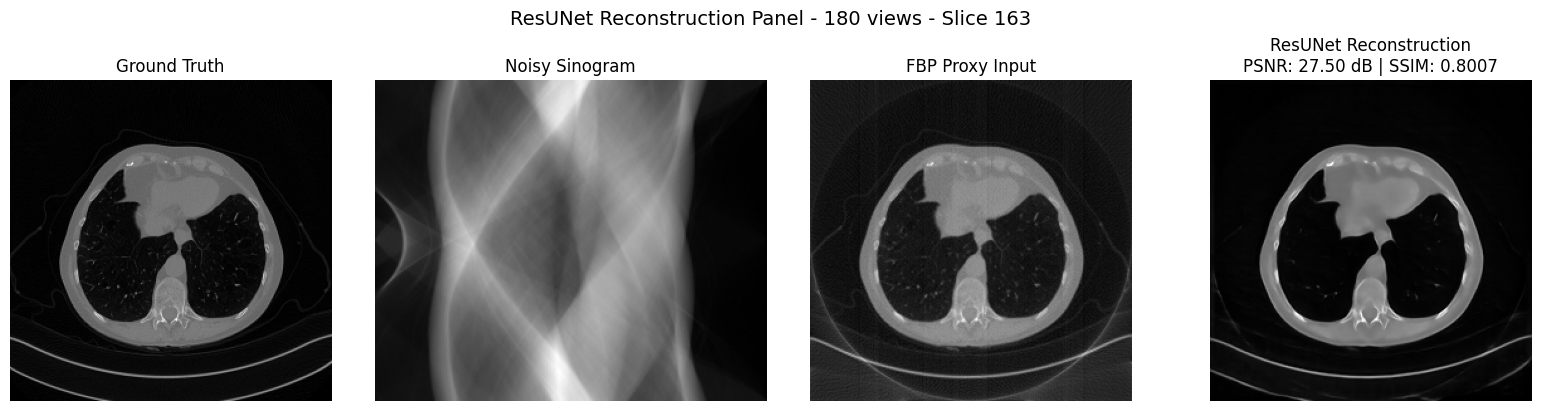

Saved ResUNet reconstruction panel for 180 views: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/outputs/unet/resunet_reconstruction_panel_180.png


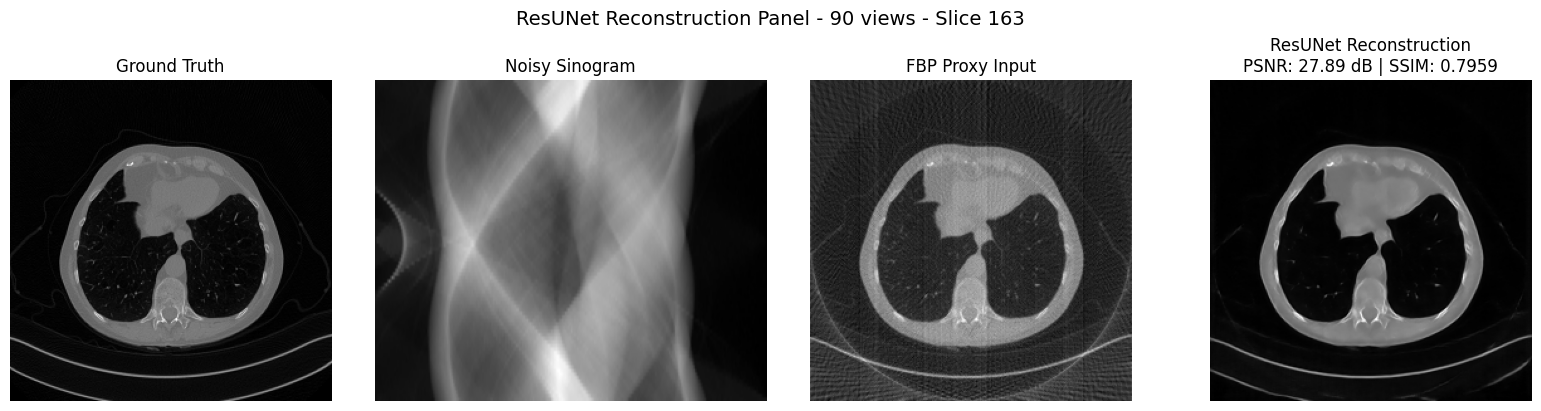

Saved ResUNet reconstruction panel for 90 views: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/outputs/unet/resunet_reconstruction_panel_90.png


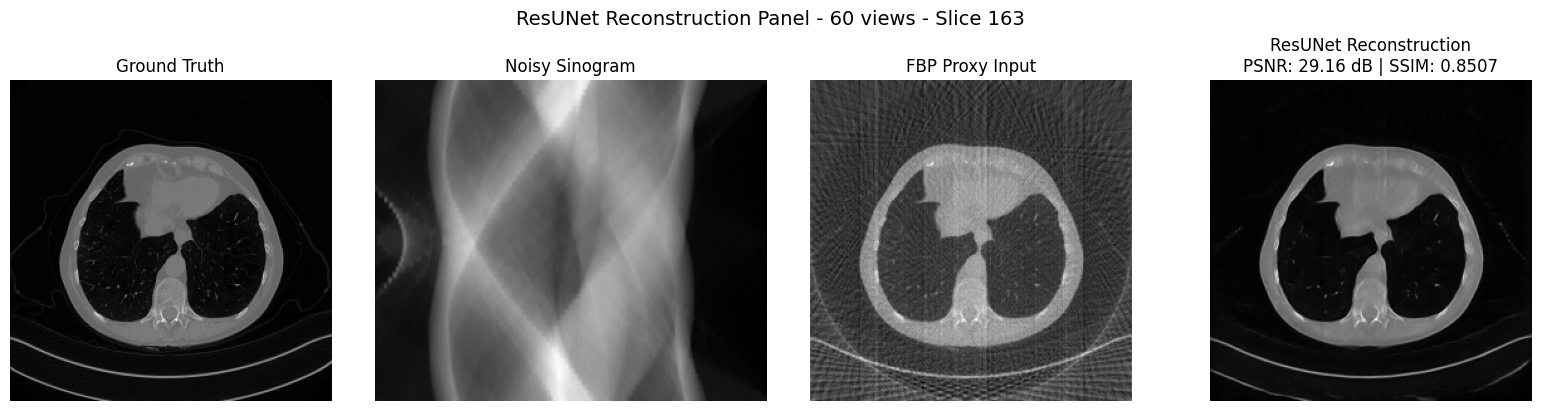

Saved ResUNet reconstruction panel for 60 views: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/outputs/unet/resunet_reconstruction_panel_60.png


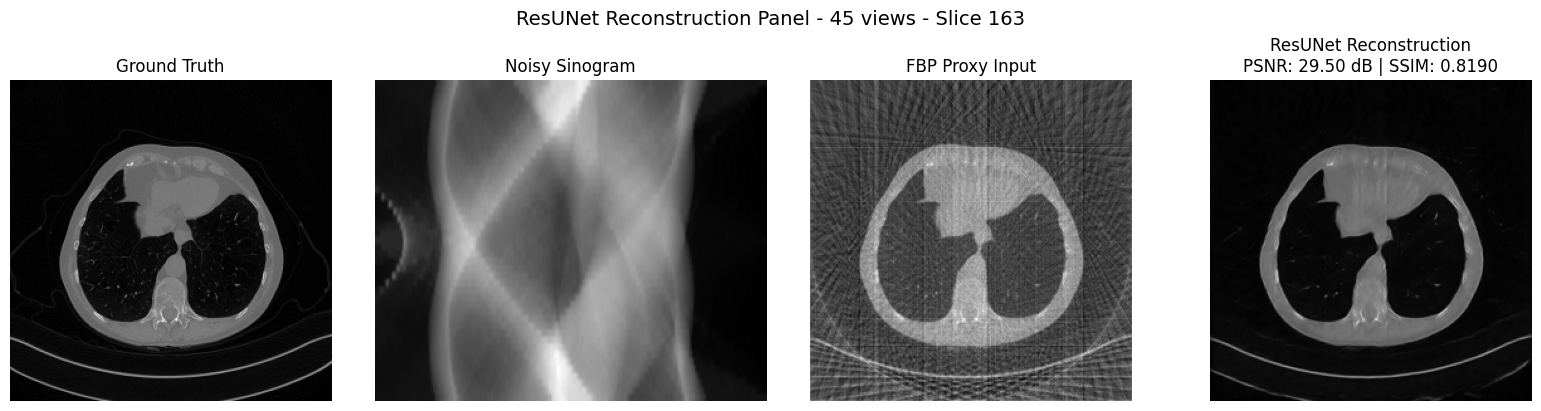

Saved ResUNet reconstruction panel for 45 views: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/outputs/unet/resunet_reconstruction_panel_45.png


In [9]:
for angle_key in [str(n) for n in ANGLE_COUNTS]:
    example = comparison_examples[angle_key]
    gt_img = torch.clamp(example["clean"][0, 0], 0.0, 1.0).numpy()
    noisy_sino = example["sinogram"][0, 0].squeeze().numpy()
    fbp_img = torch.clamp(example["fbp"][0, 0], 0.0, 1.0).numpy()
    resunet_img = torch.clamp(example["resunet"][0, 0], 0.0, 1.0).numpy()

    fig, axes = plt.subplots(1, 4, figsize=(16, 4), constrained_layout=True)
    fig.suptitle(f"ResUNet Reconstruction Panel - {angle_key} views - Slice {slice_idx}", fontsize=14)

    axes[0].imshow(gt_img, cmap="gray", vmin=0.0, vmax=1.0)
    axes[0].set_title("Ground Truth")
    axes[0].axis("off")

    axes[1].imshow(noisy_sino, cmap="gray", aspect="auto")
    axes[1].set_title("Noisy Sinogram")
    axes[1].axis("off")

    axes[2].imshow(fbp_img, cmap="gray", vmin=0.0, vmax=1.0)
    axes[2].set_title("FBP Proxy Input")
    axes[2].axis("off")

    axes[3].imshow(resunet_img, cmap="gray", vmin=0.0, vmax=1.0)
    axes[3].set_title(f"ResUNet Reconstruction\nPSNR: {evaluation_results[angle_key]['resunet_psnr']:.2f} dB | SSIM: {evaluation_results[angle_key]['resunet_ssim']:.4f}")
    axes[3].axis("off")

    output_fig_path = OUTPUT_DIR / f"resunet_reconstruction_panel_{angle_key}.png"
    fig.savefig(output_fig_path, dpi=150)
    plt.show()
    plt.close(fig)

    print(f"Saved ResUNet reconstruction panel for {angle_key} views:", output_fig_path)

## 10. Quantitative Results Summary Table

Print PSNR and SSIM for each sparse-view configuration.

In [10]:
print("="*55)
print(f"{ 'VIEWS':<10} | { 'METHOD':<16} | { 'PSNR (dB)':<12} | { 'SSIM':<8}")
print("="*55)
for angle_key in [str(n) for n in ANGLE_COUNTS]:
    res = evaluation_results[angle_key]
    print(f"{ angle_key:<10} | { 'ResUNet':<16} | { res['resunet_psnr']:<12.4f} | { res['resunet_ssim']:<8.4f}")
print("="*55)

VIEWS      | METHOD           | PSNR (dB)    | SSIM    
180        | ResUNet          | 27.4951      | 0.8007  
90         | ResUNet          | 27.8897      | 0.7959  
60         | ResUNet          | 29.1550      | 0.8507  
45         | ResUNet          | 29.4953      | 0.8190  


## 11. Quantitative Plot

Plot and save PSNR/SSIM across angle counts.

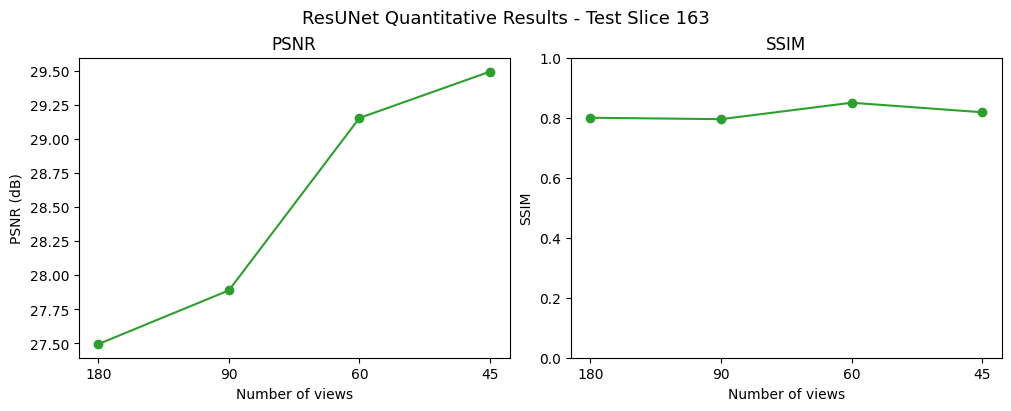

Saved ResUNet quantitative plot: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/outputs/unet/resunet_quantitative_results_all_views.png


In [11]:
view_labels = [str(n) for n in ANGLE_COUNTS]
psnr_values = [evaluation_results[key]["resunet_psnr"] for key in view_labels]
ssim_values = [evaluation_results[key]["resunet_ssim"] for key in view_labels]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
fig.suptitle(f"ResUNet Quantitative Results - Test Slice {slice_idx}", fontsize=13)

axes[0].plot(view_labels, psnr_values, marker="o", color="tab:green")
axes[0].set_xlabel("Number of views")
axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("PSNR")

axes[1].plot(view_labels, ssim_values, marker="o", color="tab:green")
axes[1].set_ylim(0.0, 1.0)
axes[1].set_xlabel("Number of views")
axes[1].set_ylabel("SSIM")
axes[1].set_title("SSIM")

plot_path = OUTPUT_DIR / "resunet_quantitative_results_all_views.png"
fig.savefig(plot_path, dpi=150)
plt.show()
plt.close(fig)

print("Saved ResUNet quantitative plot:", plot_path)